In [1]:
import pickle
import os
import gpflow
import numpy as np
f64 = gpflow.utilities.to_default_float
import matplotlib.pylab as plt
import pandas as pd
import bambi as bmb
from matplotlib.ticker import MaxNLocator


In [2]:
for c in range(11):
    globals()[f'particles_summary{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/particles_summary{c}.pkl", mode="rb"))
    globals()[f'threshold{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/threshold{c}.pkl", mode="rb"))
    globals()[f'weight{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/weight{c}.pkl", mode="rb"))
    globals()[f'index{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/p_index_{c}.pkl", mode="rb"))
    globals()[f'mad{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/mad{c}.pkl", mode="rb"))
    globals()[f'r_s_mean{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/r_s_mean{c}.pkl", mode="rb"))
    globals()[f'r_s_median{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/gpsep/r_s_median{c}.pkl", mode="rb"))
mad_all = np.vstack([globals()[f'mad{i}'] for i in range(11)])
threshold_all = np.vstack([globals()[f'threshold{i}'] for i in range(11)])
r_s_mean = np.vstack([globals()[f'r_s_mean{i}'] for i in range(11)])
r_s_median = np.vstack([globals()[f'r_s_median{i}'] for i in range(11)])

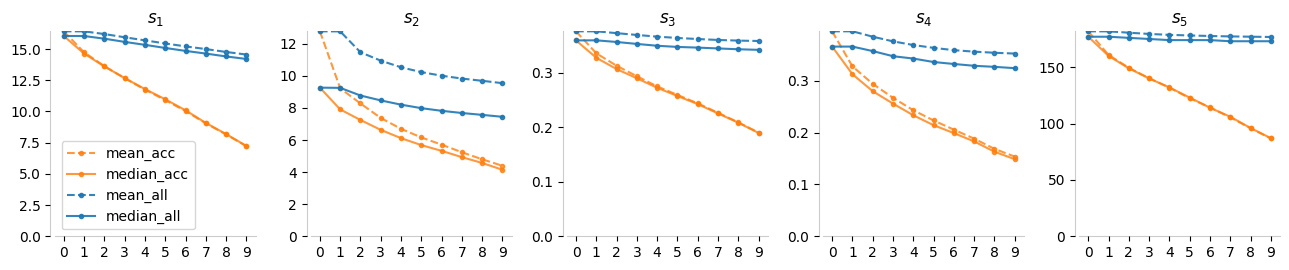

In [10]:
fig = plt.figure(figsize=(13, 2.8))
for j in range(5):
    ax = fig.add_subplot(1, 5, j+1)
    ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    m0 = []
    m1 = []
    m2 = []
    for i in range(10):
        m0.append(np.round(np.nanmean(globals()[f'particles_summary{i}'][:, j]), 4))
        m1.append(np.round(np.nanmedian(globals()[f'particles_summary{i}'][:, j]), 4))
    
    plt.plot(m0, '.--', label='mean_acc', color = 'C1', alpha=0.8)
    plt.plot(m1, '.-', label='median_acc', color = 'C1', alpha=0.8)

    plt.plot(r_s_mean[:10, j], '.--', label='mean_all', color = 'C0', alpha=0.9)
    plt.plot(r_s_median[:10, j], '.-', label='median_all', color = 'C0', alpha=0.9) 
    plt.title(f"$s_{j+1}$")
    if j == 0: 
        plt.legend(fontsize=10)
    
    plt.ylim((0, np.max(m0)))
plt.tight_layout()
# plt.savefig('plot112_2.pdf')  

plt.show()

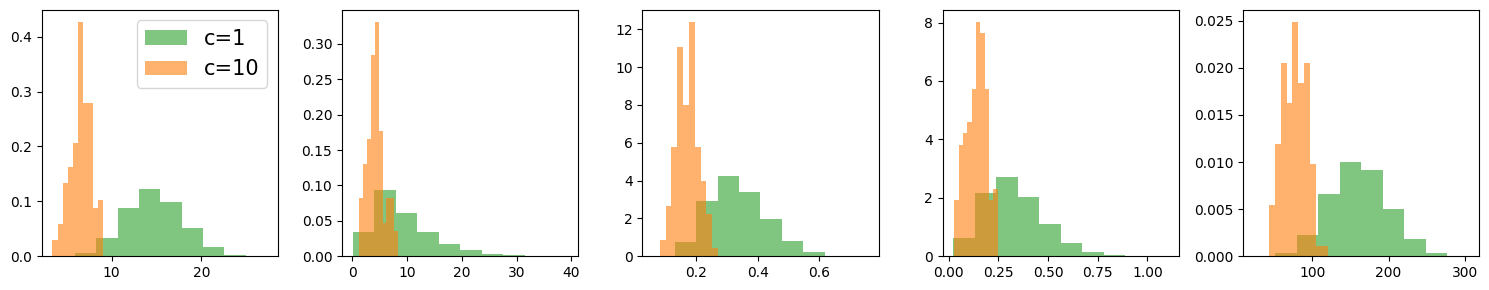

In [6]:
fig = plt.figure(figsize=(15, 3))
for j in range(5):
    ax = fig.add_subplot(1, 5, j+1)

    plt.hist(globals()[f'particles_summary{1}'][:, j], color = f'C{2}', density=True, alpha=0.6, label=f'c={1}')
    plt.hist(globals()[f'particles_summary{10}'][:, j], color = f'C{1}', density=True, alpha=0.6, label=f'c={10}')
    if j == 0: plt.legend(fontsize=15)
plt.tight_layout()
# plt.savefig('plot102.pdf')  

plt.show()

In [7]:
for c in range(11):
    print(globals()[f'threshold{c}'])

10.823122298066643
9.697670882744736
9.004608987088703
8.41235206172071
7.924955330282427
7.3863955552701785
6.782484410395819
6.18657022566585
5.558880887297172
5.044609220548391
4.639984858874871


In [8]:
# the number of neighbours
for c in range(0, 9):
    neighbour =[] 
    current_index_simu = globals()[f'index{c}']
    for kk in range(current_index_simu.shape[0]): 
        neighbour.append(np.sum(np.sum(current_index_simu[kk] == current_index_simu, axis=1) >= 4)-1)

    print(np.sum(np.array(neighbour) > 0))

0
51643
38230
17091
15456
8754
4079
2176
987


In [6]:
# number of uniques
1000060
501869
300173
150650
100435
60039
30036
15026
7002
1000
120

64858
28965
21966
11572
3496
1183


In [9]:

print((1000060 - 0)*5*5000) 
print((501869 - 51643)*5*5000) 
print((300173 - 38230)*5*5000) 
print((150650 - 17091)*5*5000) 
print((100435- 15456)*5*5000) 
print((60039 - 8754)*5*5000)
print((30036 - 4079)*5*5000)
print((15026 - 2176)*5*5000)
print((7002 - 987)*5*5000)
print((1000 - 63)*5*5000)

25001500000
11255650000
6548575000
3338975000
2124475000
1282125000
648925000
321250000
150375000
23425000


In [10]:
for c in range(11):
    print(1 / np.sum(globals()[f'weight{c}'] ** 2))

1000060.0000000015
501875.00000000064
298440.9423112147
147751.9956451955
97641.93532851795
57435.735469588304
28166.420463544262
13801.45696701106
6301.851663602874
887.0903472743227
96.5039324206234


In [11]:
print((1000060.0000000015- 0)*5*5000) 
print((501875.00000000064 - 51643)*5*5000) 
print((298440.9423112147 - 38230)*5*5000) 
print((147751.9956451955 - 17091)*5*5000) 
print((97641.93532851795- 15456)*5*5000) 
print((57435.735469588304 - 8754)*5*5000)
print((28166.420463544262 - 4079)*5*5000)
print((13801.45696701106 - 2176)*5*5000)
print((6301.851663602874 - 987)*5*5000)
print((887.0903472743227 - 63)*5*5000)
print((96.5039324206234 - 6)*5*5000)

25001500000.00004
11255800000.000017
6505273557.780368
3266524891.1298876
2054648383.2129488
1217043386.7397077
602185511.5886065
290636424.17527646
132871291.59007186
20602258.681858066
2262598.310515585


In [12]:
# acc rate
print(501875 /1000000)
print(300176/1070000)
print(150650/1040000)
print(100435/1500000)
print(60040/2190000)
print(30036/3120000)
print(15026/6370000)
print(7003/16740000)
print(1000/19980000)
print(120/17830000)
p_acc = [1, 501875 /1000000, 300176/1070000, 150650/1040000, 100435/1500000, 60040/2190000,30036/3120000,
         15026/6370000, 7003/16740000, 1000/19980000, 120/17830000]

0.501875
0.2805383177570093
0.14485576923076923
0.06695666666666666
0.02741552511415525
0.009626923076923076
0.0023588697017268446
0.0004183393070489845
5.005005005005005e-05
6.730229949523275e-06


In [25]:
p_prior = [1, 0.4998712037350917, 0.2502022441349201, 0.1101045069692979, 0.042241275003024915, 0.013908296659396878, 0.0037837902700821676, 0.0006942798658838893, 8.599750607232391*10**(-5), 8.299759306980098*10**(-6), 9.999710008409756*10**(-7)]
number_prior = [10000290, 4998857, 2502095, 1101077, 422425, 139087, 37839, 6943, 860, 83, 10]

In [26]:
t_c = np.array([53.15, 75.17, 77.78, 74.55, 107.97, 158.12,225.1, 453.22, 1182.57 ,1433.43 ,  1270.50])
cum_t_c = np.cumsum(t_c)
N_c = np.array([1000060, 501875 ,300176, 150650, 100435, 60040, 30036, 15026 ,  7003 ,  1000,  120])
E_c1 = number_prior * (cum_t_c / 530.5 )
E_c2 = number_prior * (t_c / 530.5 )
t_E = (N_c/number_prior) *530.5 

In [22]:
number_prior

[1000060, 500030, 250537, 109949, 42067, 13765, 3806, 695, 91, 8, 0]

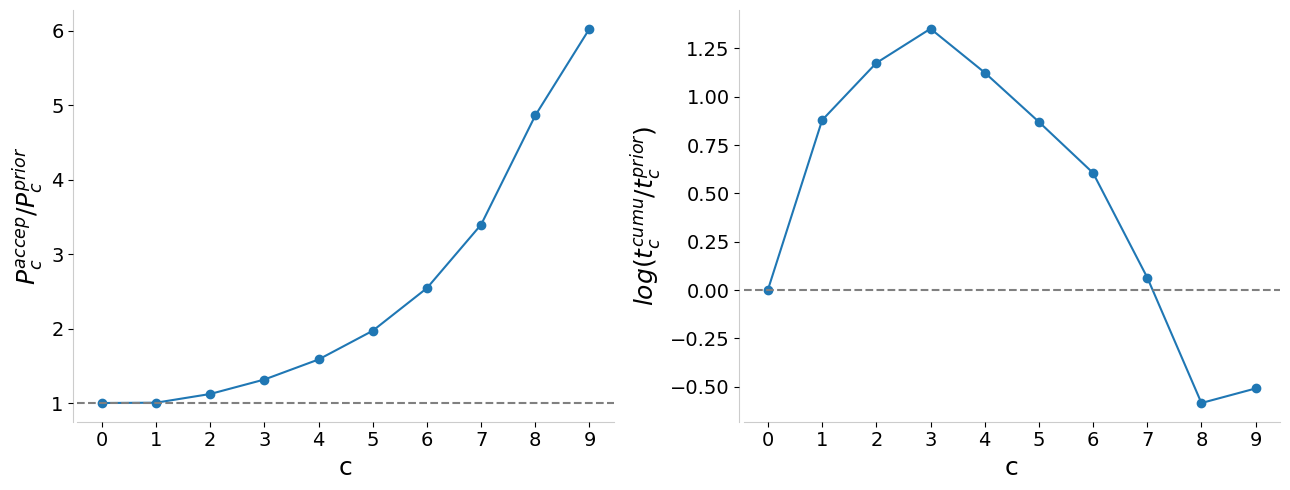

In [28]:
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.array(p_acc[:10])/np.array(p_prior[:10]), '-o')
plt.ylabel(r"$P^{accep}_c"+"     /       " +r"P_{c}^{prior}$", fontsize=18)
plt.xlabel('c', fontsize=18)
plt.axhline(1, linestyle='--', color='grey')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax = fig.add_subplot(1, 2, 2)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.log(cum_t_c/t_E)[:10], '-o')
# plt.plot(N_c/E_c2, '-o')
plt.ylabel(r"$log(t^{cumu}_c"+"     /       " +r"t_{c}^{prior})$", fontsize=18)
plt.xlabel('c', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.axhline(0, linestyle='--', color='grey')
plt.tight_layout()

# plt.savefig('plot132.pdf')  


In [39]:
truedata_style='gp'
grw_setting='sep'
model_type = 'gpabc'
grw = {}
# for c in range(11):
for c in [1,4,6,9, 10]:
    grw[f'c = {c}'] = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+f"/growth_rate{c}.pkl", mode="rb"))
df = pd.DataFrame(np.real(pd.DataFrame(grw)), columns=pd.DataFrame(grw).columns)


In [40]:
from s0_fun_IPMs import IPM_listk, kernel_setting

gp_mle_true_models = pickle.load(open(file = os.getcwd()+f"/true_popu/gp_mle_true_models.pkl", mode="rb"))
gp_mle_true_population = pickle.load(open(file = os.getcwd()+f"/true_popu/gp_mle_true_population/gp_mle_true_population.pkl", mode="rb")) 
# IPM Mesh setting
lower_p = 0
upper_p = 5
m_size_p = 50
mesh_setting = kernel_setting(m_size_p, lower_p, upper_p)
Xp = mesh_setting[0]
step_size = m_size_p // 5
ticks = [i * step_size for i in range(0, 6)]
ticks[-1] = m_size_p - 1

# IPMs for true models
# true_p_glm, true_f_glm = IPM_listk(mesh_setting=mesh_setting, models=glm_mle_true_models, grw_setting='sep')
true_p_gp, true_f_gp = IPM_listk(mesh_setting=mesh_setting, models=gp_mle_true_models, grw_setting='sep')
observed_lambda_gp = (np.sum(np.isnan(gp_mle_true_population["size"])) + np.sum(gp_mle_true_population["surv"] == 1)) / np.sum(np.logical_not(np.isnan(gp_mle_true_population["size"])))

# lambdas
# true_lambda_glm = np.linalg.eig(true_p_glm+true_f_glm)[0][0]; print(true_lambda_glm)
true_lambda_gp = np.linalg.eig(true_p_gp+true_f_gp)[0][0]

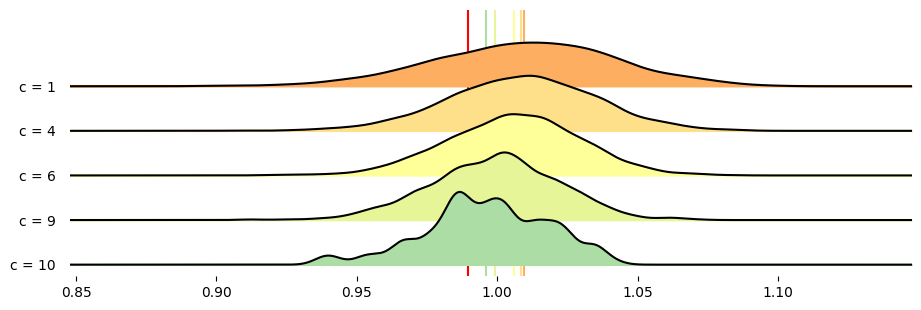

In [42]:
import joypy
import random
# Sample data
colors = ["#FDAE61", "#FEE08B", "#FFFFBF", "#E6F598", "#ABDDA4"]
colors = ["#FDAE61", "#FEE08B", "#FFFF99", "#E6F598", "#ABDDA4"]

# colors = ["#CEF4D2", "#7BE495", "#56C596", "#329D9C", "#205072"]

fig, ax = joypy.joyplot(df, color=colors)
fig.set_size_inches((10, 3))
plt.axvline(true_lambda_gp.real, color='red', label='true')
plt.axvline(df.mean()[0], color=colors[0])
plt.axvline(df.mean()[1], color=colors[1])
plt.axvline(df.mean()[2], color=colors[2])
plt.axvline(df.mean()[3], color=colors[3])
plt.axvline(df.mean()[4], color=colors[4])